In [38]:
# imports
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [39]:
# Load the csv file
df = pd.read_csv('data/data.csv')

feature_names = df.columns[:-1].to_list()
features = df.iloc[:, :-1].values
labels = df.iloc[:, -1].values
classes = np.unique(labels)

In [40]:
# ECM clustering
from evclust.ecm import ecm
model = ecm(x=features, c=2, beta = 1.3,  alpha=1, delta=3, disp=False)

F = model['F']
M = model['mass']

In [41]:
def get_centroids(M, features):
    num_samples = M.shape[0]
    num_metaclusters = M.shape[1]
    feat_dim = features.shape[1]
    
    centroids = np.zeros((num_metaclusters, feat_dim))
    for i in range(num_metaclusters):
        for j in range(num_samples):
            centroids[i] += M[j, i] * features[j] / np.sum(M[:, i])

    return centroids[1:]  # remove the first centroid, which is the outliers

In [42]:
def get_dist_matrix(features, centroids):
    num_samples = features.shape[0]
    num_metaclusters = centroids.shape[0]
    
    dis_matrix = np.zeros((num_samples, num_metaclusters))
    for i in range(num_samples):
        for j in range(num_metaclusters):
            dis_matrix[i, j] = np.linalg.norm(features[i] - centroids[j])

    min_dis = np.min(dis_matrix, axis=1).reshape(-1, 1)
    # concatenate the 1/min_dis as first column
    dis_matrix = np.concatenate((1/min_dis, dis_matrix), axis=1)
    
    return dis_matrix

In [43]:
def xiebeni_index(M, features, transform_fn = lambda x : x):
    num_samples = M.shape[0]

    centroids = get_centroids(M, features)
    distances = get_dist_matrix(features, centroids)

    # min dist between two different centroids
    min_dis = np.inf
    for i in range(centroids.shape[0]):
        for j in range(i + 1, centroids.shape[0]):
            dis = np.linalg.norm(centroids[i] - centroids[j])
            if dis < min_dis:
                min_dis = dis

    u = transform_fn(M)
    xb = np.sum((distances**2)*u)/num_samples
    xb = xb/(min_dis**2)
    return xb

In [44]:
xiebeni_index(M, features)

0.5361860844520856

In [45]:
def jaccard_matrix_calculus(number_metaclasses):
    """
    Compute the Jaccard matrix for the disernment framework of the given mass function
    """
    natoms = round(np.log2(number_metaclasses))
    ind = [{}]*number_metaclasses
    if (np.power(2, natoms) == number_metaclasses):
        ind[0] = {0} #In fact, the first element should be a None value (for empty set).
        #But in the following calculate, we'll deal with 0/0 which shoud be 1 bet in fact not calculable. So we "cheat" here to make empty = {0}
        ind[1] = {1}
        step = 2
        while (step < number_metaclasses):
            ind[step] = {step}
            step = step+1
            indatom = step
            for step2 in range(1,indatom - 1):
                ind[step] = (ind[step2] | ind[indatom-1])
                step = step+1
    out = np.zeros((number_metaclasses,number_metaclasses))

    for i in range(number_metaclasses):
        for j in range(number_metaclasses):
            out[i][j] = float(len(ind[i] & ind[j]))/float(len(ind[i] | ind[j]))

    out[0,0] = 0
    return out

In [46]:
S_1 = jaccard_matrix_calculus(M.shape[1])

In [50]:
M.shape

(202, 4)

In [51]:
S_1.shape

(4, 4)

In [69]:
def transform(M, sim_matrix, fuzzifier_factor):
    M = M**fuzzifier_factor
    M = np.dot(M, sim_matrix)
    # M = M / np.sum(M, axis=1).reshape(-1, 1)
    return M

/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/ecm.py:163: RuntimeWarning: invalid value encountered in power
  J = np.nansum((m ** beta) * D[:, :f - 1] * np.tile(card[:f - 1] ** alpha, (n, 1))) + delta2 * np.nansum(mvide[:f - 1] ** beta)


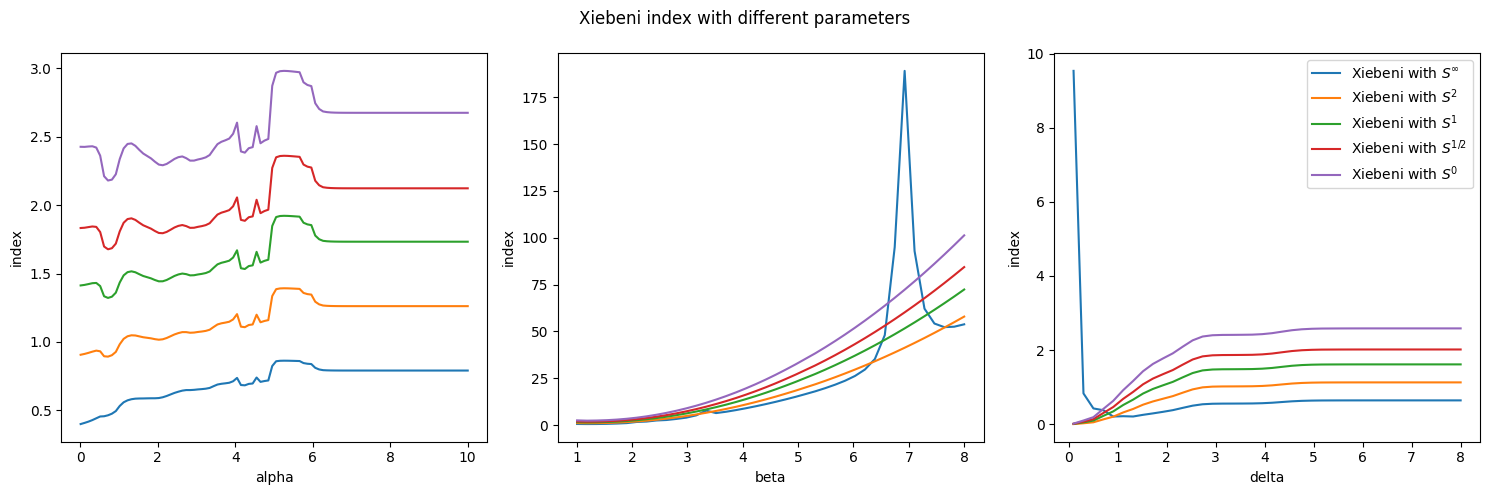

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

def ECM_test_index(index_fn, name, ax = ax, pars_default = (1, 1.1, 3)):
    xbss_alpha = []
    for alpha in np.linspace(0.01, 7, 70):
        try:
            model = ecm(x=features, c=2, beta=pars_default[1], alpha=alpha, delta=pars_default[2], disp=False)
            xb = index_fn(model['mass'], features)
            xbss_alpha.append((alpha, xb))
        except Exception as e:
            print(f"Error with alpha {alpha}: {e}")
    xbss_beta = []
    for beta in np.linspace(1.01, 8, 40):
        try:
            model = ecm(x=features, c=2, beta=beta, alpha=pars_default[1], delta=pars_default[2], disp=False)
            xb = index_fn(model['mass'], features)
            xbss_beta.append((beta, xb))
        except Exception as e:
            print(f"Error with beta {beta}: {e}")
    xbss_delta = []
    for delta in np.linspace(0.1, 2, 40):
        try:
            model = ecm(x=features, c=2, beta=pars_default[1], alpha=pars_default[1], delta=delta, disp=False)
            xb = index_fn(model['mass'], features)
            xbss_delta.append((delta, xb))
        except Exception as e:
            print(f"Error with delta {delta}: {e}")
    xbss_alpha = np.array(xbss_alpha)
    xbss_beta = np.array(xbss_beta)
    xbss_delta = np.array(xbss_delta)

    ax[0].plot(xbss_alpha[:, 0], xbss_alpha[:, 1], label=name)
    ax[0].set_xlabel('alpha')
    ax[0].set_ylabel('index')
    ax[1].plot(xbss_beta[:, 0], xbss_beta[:, 1], label=name)
    ax[1].set_xlabel('beta')
    ax[1].set_ylabel('index')
    ax[2].plot(xbss_delta[:, 0], xbss_delta[:, 1], label=name)
    ax[2].set_xlabel('delta')
    ax[2].set_ylabel('index')

# Plotting the Xiebeni index
ECM_test_index(xiebeni_index, name='Xiebeni with $S^\infty$')
# Plotting the Xiebeni index with transformation
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, S_1**2, 1)), name='Xiebeni with $S^2$')
# Plotting the Xiebeni index with transformation
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, S_1, 1)), name='Xiebeni with $S^1$')
# Plotting the Xiebeni index with transformation
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, S_1**(1/2), 1)), name='Xiebeni with $S^{1/2}$')
# Plotting the Xiebeni index with transformation
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, np.ceil(S_1), 1)), name='Xiebeni with $S^0$')
plt.legend()
plt.suptitle('Xiebeni index with different parameters')
plt.tight_layout()
plt.show()


In [75]:
upper_diagonal_ones = np.triu(np.ones((S_1.shape[0], S_1.shape[1])), k=0)
upper_S_1 = S_1 * upper_diagonal_ones
down_S_1 = upper_S_1.T

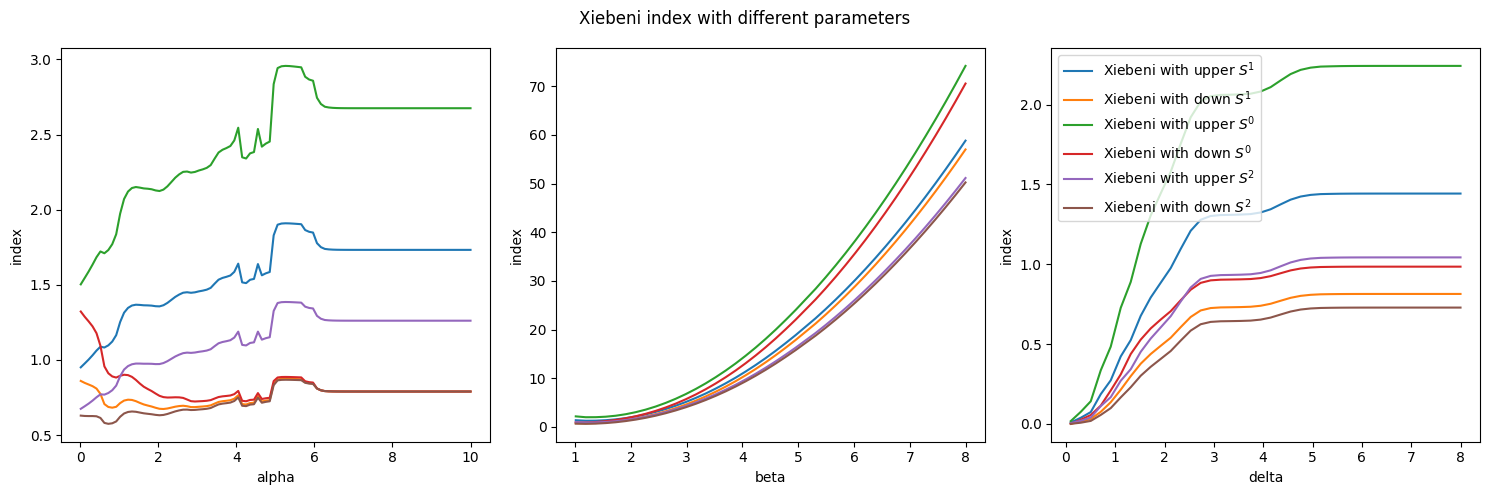

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, upper_S_1, 1)), name='Xiebeni with upper $S^1$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, down_S_1, 1)), name='Xiebeni with down $S^1$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, np.ceil(upper_S_1), 1)), name='Xiebeni with upper $S^0$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, np.ceil(down_S_1), 1)), name='Xiebeni with down $S^0$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, upper_S_1**2, 1)), name='Xiebeni with upper $S^2$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, down_S_1**2, 1)), name='Xiebeni with down $S^2$', ax=ax)
plt.legend()
plt.suptitle('Xiebeni index with different parameters')
plt.tight_layout()
plt.show()

/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/ecm.py:121: RuntimeWarning: overflow encountered in power
  vect1 = (np.tile(D[i, j], f-1) / vect0) ** (1 / (beta-1))
/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/ecm.py:123: RuntimeWarning: overflow encountered in multiply
  vect3 = vect1 * vect2
/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/utils.py:205: RuntimeWarning: divide by zero encountered in divide
  C = 1 / (1 - conf)
/Users/victor/Documents/GitHub/clustering-examples/.venv/lib/python3.9/site-packages/evclust/ecm.py:163: RuntimeWarning: invalid value encountered in power
  J = np.nansum((m ** beta) * D[:, :f - 1] * np.tile(card[:f - 1] ** alpha, (n, 1))) + delta2 * np.nansum(mvide[:f - 1] ** beta)


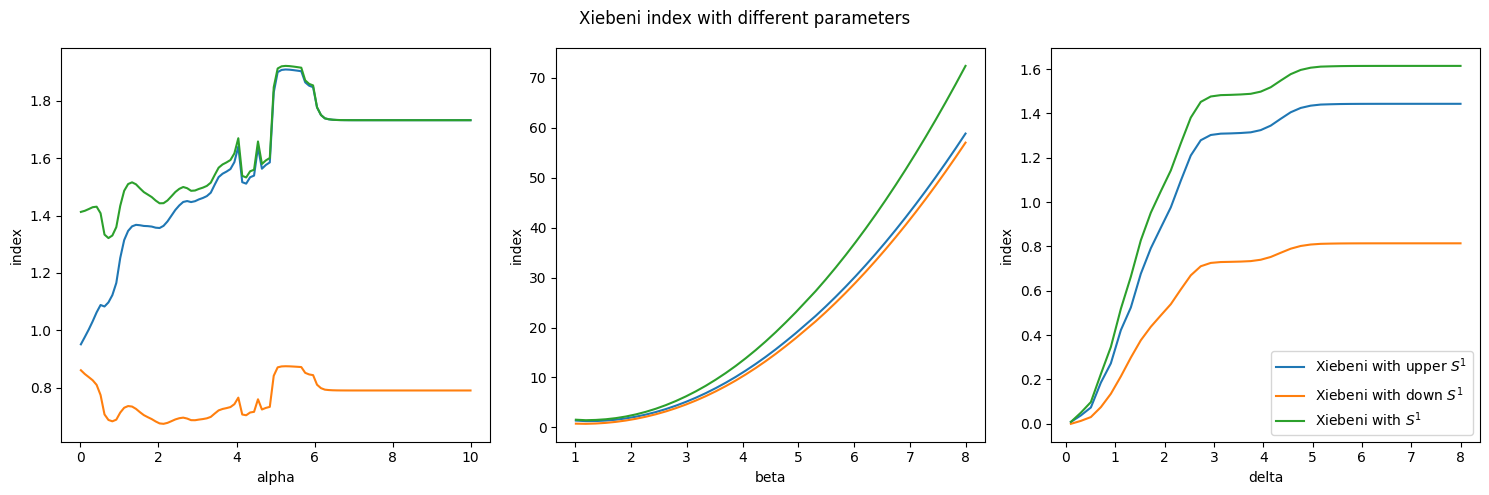

In [77]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, upper_S_1, 1)), name='Xiebeni with upper $S^1$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, down_S_1, 1)), name='Xiebeni with down $S^1$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, S_1, 1)), name='Xiebeni with $S^1$', ax=ax)
plt.legend()
plt.suptitle('Xiebeni index with different parameters')
plt.tight_layout()
plt.show()

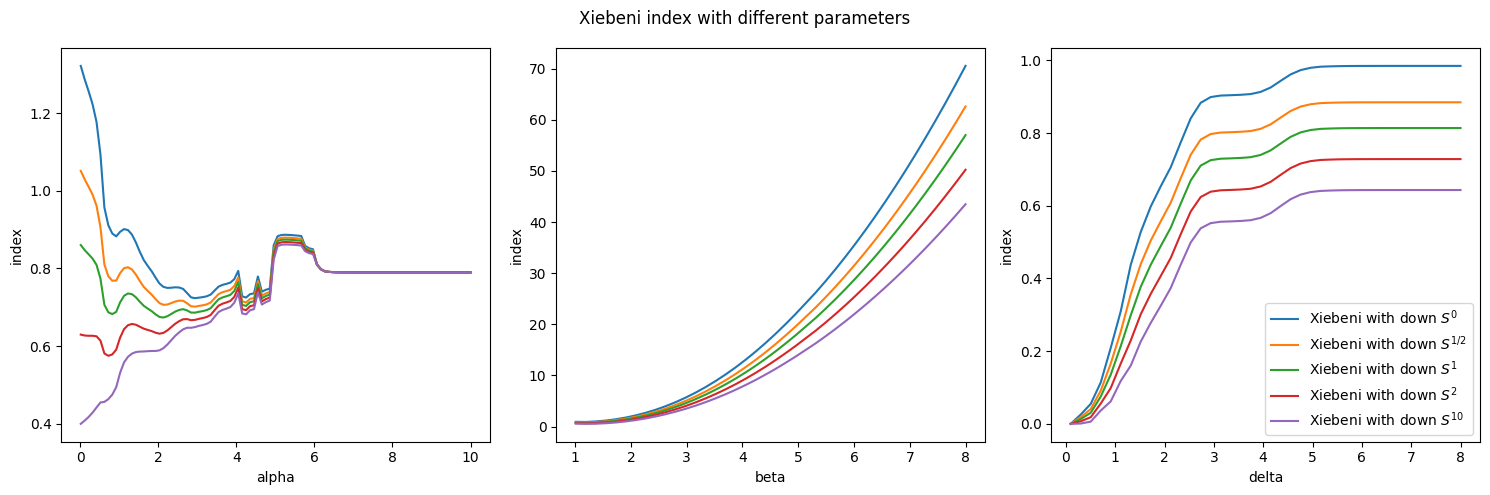

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, np.ceil(down_S_1), 1)), name='Xiebeni with down $S^0$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, down_S_1**(1/2), 1)), name='Xiebeni with down $S^{1/2}$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, down_S_1, 1)), name='Xiebeni with down $S^1$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, down_S_1**2, 1)), name='Xiebeni with down $S^2$', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, down_S_1**10, 1)), name='Xiebeni with down $S^{10}$', ax=ax)
ECM_test_index(xiebeni_index, name='Xiebeni with $S^\infty$', ax=ax)
# ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform(x, np.exp(-down_S_1), 1)), name='Xiebeni with down $S^{-1}$', ax=ax)
plt.legend()
plt.suptitle('Xiebeni index with different parameters')
plt.tight_layout()
plt.show()

In [101]:
def transform2(M, cautiousness_factor, fuzzifier_factor):
    cardinalities = F.sum(axis=1).reshape(-1, 1)
    # repeat the cardinalities to match the shape of M
    cardinalities = np.repeat(cardinalities, M.shape[1], axis=1)
    
    M = (M**fuzzifier_factor) * (np.repeat(F.sum(axis=1).reshape(-1, 1), M.shape[0], axis=1).T**cautiousness_factor)

    return M

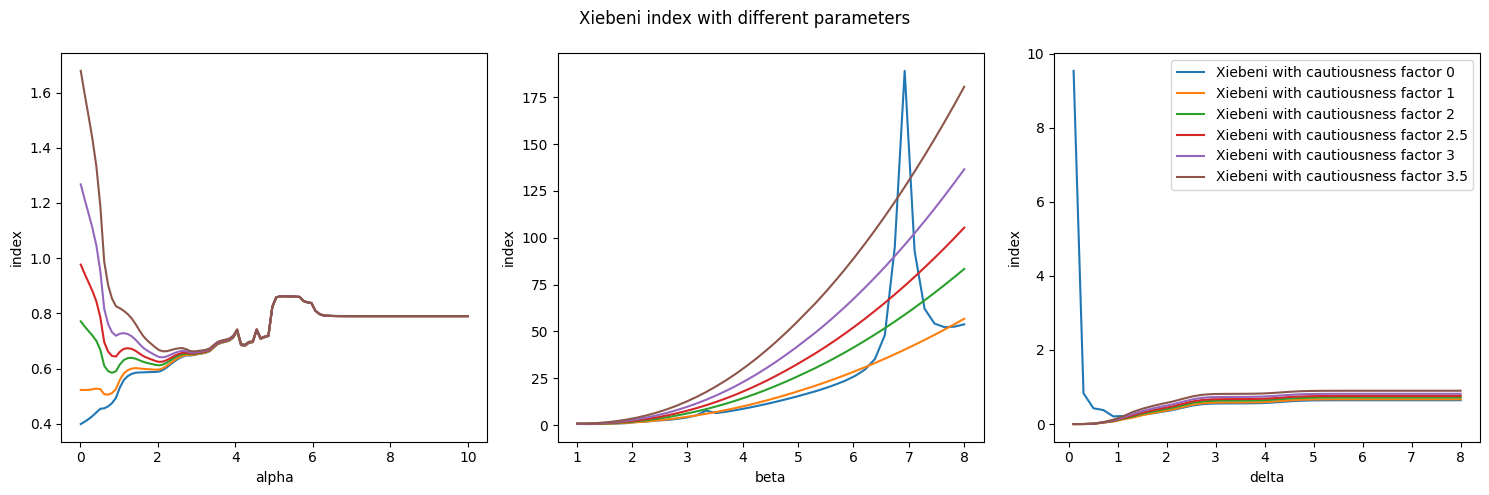

In [107]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform2(x, 0, 1)), name='Xiebeni with cautiousness factor 0', ax=ax)
# ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform2(x, 0.1, 1)), name='Xiebeni with cautiousness factor 0.1', ax=ax)
# ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform2(x, 0.5, 1)), name='Xiebeni with cautiousness factor 0.5', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform2(x, 1, 1)), name='Xiebeni with cautiousness factor 1', ax=ax)
# ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform2(x, 1.5, 1)), name='Xiebeni with cautiousness factor 1.5', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform2(x, 2, 1)), name='Xiebeni with cautiousness factor 2', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform2(x, 2.5, 1)), name='Xiebeni with cautiousness factor 2.5', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform2(x, 3, 1)), name='Xiebeni with cautiousness factor 3', ax=ax)
ECM_test_index(lambda M, features: xiebeni_index(M, features, transform_fn=lambda x: transform2(x, 3.5, 1)), name='Xiebeni with cautiousness factor 3.5', ax=ax)
plt.legend()
plt.suptitle('Xiebeni index with different parameters')
plt.tight_layout()
plt.show()

In [90]:
M.shape

(202, 4)

In [99]:
np.repeat(F.sum(axis=1).reshape(-1, 1), M.shape[0], axis=1).T.shape

(202, 4)